<a href="https://colab.research.google.com/github/Sameer0Rai/Deep-Learning/blob/main/Lab-Assignments/Lab_6_Learning_to_Bend_a_Model_(Guided_Workshop).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# fixing a random seed so that the results remain the same
# every time the notebook is run
np.random.seed(42)

In [2]:
# creating input feature X
# we want 50 samples between 0 and 10

X = np.linspace(0, 10, 50).reshape(-1, 1)

# X is the only input feature for our model.
# choosing values between 0 and 10 lets us see
# both the early fast change and the later slower growth.
# this makes it easier to observe why a linear model struggles
# with curved patterns.

In [3]:
# generating a small amount of noise so the data
# does not look perfectly smooth

noise = np.random.normal(0, 0.2, size=(50,1))

# creating a nonlinear relationship
y = np.log(X + 1) + noise

# the logarithmic curve increases quickly in the beginning
# but then starts flattening out.
# a straight line cannot match both behaviors at the same time,
# which is exactly why we need a model that can "bend".

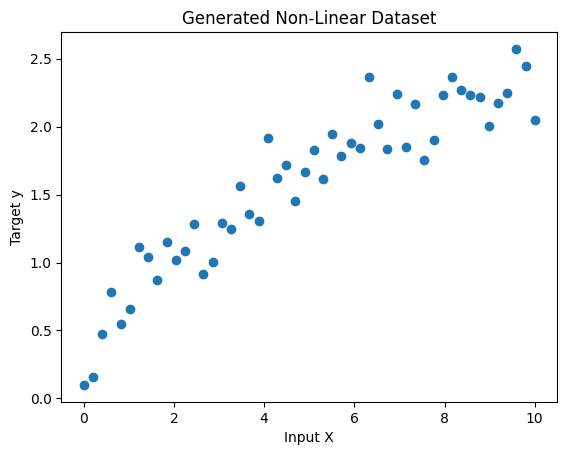

In [4]:
# plotting the generated data so we can see the shape
# of the relationship before training the model

plt.scatter(X, y)
plt.title("Generated Non-Linear Dataset")
plt.xlabel("Input X")
plt.ylabel("Target y")
plt.show()

In [5]:
# defining the size of each layer in the network

input_units = 1
hidden_units = 3
output_units = 1

# we choose 3 hidden units so the model can capture
# more flexible patterns than a simple straight line.

# using more than one hidden unit allows the network
# to combine multiple simple behaviors to form a curve.

# we avoid using too many units because it would make
# the model unnecessarily complex and harder to train.

In [6]:
# initializing weights and biases

# weights connecting input layer to hidden layer
W1 = np.random.uniform(-1, 1, size=(input_units, hidden_units))

# bias for hidden layer neurons
b1 = np.zeros((1, hidden_units))

# weights connecting hidden layer to output
W2 = np.random.uniform(-1, 1, size=(hidden_units, output_units))

# bias for the output neuron
b2 = np.zeros((1, output_units))

# weights mainly control how strongly signals move
# from one layer to the next and therefore affect
# the shape of the learned function.

# biases shift the activation of neurons and help
# the model adjust the position of the curve.

In [7]:
# defining the activation function

def activation(z):
    # ReLU keeps positive values and removes negatives
    return np.maximum(0, z)


def activation_slope(z):
    # derivative of ReLU
    # slope is 1 when z > 0 and 0 otherwise
    return (z > 0).astype(float)

# the slope is important because during training
# it tells the model how the output changes when
# the parameters change slightly.
# without this information the model would not know
# which direction to update the weights.

In [8]:
learning_rate = 0.01
epochs = 1000

for epoch in range(epochs):





    # computing hidden layer input
    z1 = X @ W1 + b1

    # applying activation to introduce non-linearity
    h = activation(z1)

    # computing final prediction
    y_hat = h @ W2 + b2



    error = y_hat - y
    loss = np.mean(error ** 2)

    # squaring the error makes larger mistakes
    # contribute more strongly to the loss



    dL_dy = 2 * error / len(X)

    dL_dW2 = h.T @ dL_dy
    dL_db2 = np.sum(dL_dy, axis=0, keepdims=True)

    dL_dh = dL_dy @ W2.T

    dL_dz1 = dL_dh * activation_slope(z1)

    dL_dW1 = X.T @ dL_dz1
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)


    # parameters are updated in the opposite direction
    # of the gradient to reduce the loss

    W1 -= learning_rate * dL_dW1
    b1 -= learning_rate * dL_db1
    W2 -= learning_rate * dL_dW2


    b2 -= learning_rate * dL_db2

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

Epoch 0 | Loss: 0.2167
Epoch 100 | Loss: 0.0824
Epoch 200 | Loss: 0.0611
Epoch 300 | Loss: 0.0543
Epoch 400 | Loss: 0.0521
Epoch 500 | Loss: 0.0514
Epoch 600 | Loss: 0.0511
Epoch 700 | Loss: 0.0511
Epoch 800 | Loss: 0.0510
Epoch 900 | Loss: 0.0510


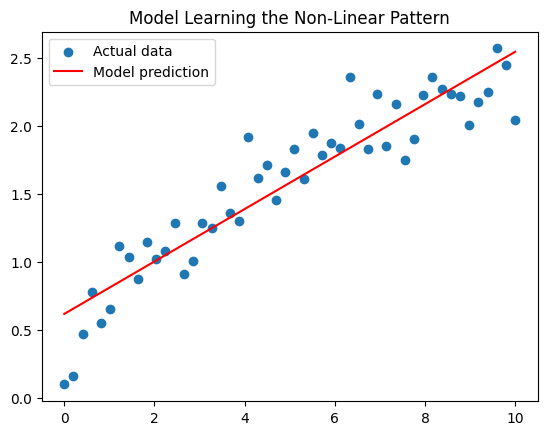

In [9]:
plt.scatter(X, y, label="Actual data")
plt.plot(X, y_hat, color="red", label="Model prediction")
plt.title("Model Learning the Non-Linear Pattern")
plt.legend()
plt.show()